# COMPAS: Preprocessing, Inprocessing, and Postprocessing Comparison

This notebook compares different fairness intervention methods on the COMPAS dataset:
- **Preprocessing**: Uniform sampling vs Reweighted sampling
- **Inprocessing**: Baseline (LinUCB) vs Fair algorithm (GroupAwareDPLinUCB)
- **Postprocessing**: With and without postprocessor

We visualize DP-gap and EO-gap over time (rounds) to show how fairness metrics evolve during the bandit process.

## Import Required Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from fair_bandits.metrics.fairness import (
    equalized_odds_gap,
    tpr_gap,
    fpr_gap,
)
from fair_bandits.metrics.temporal import aggregate_temporal_over_seeds

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

## Configuration and Data Loading

In [2]:
RESULTS_DIR = Path("results/dev")
SENSITIVE_ATTR = "sex"  # Can be "sex" or "race_binary"
DATASET_NAME = "COMPAS"

def get_experiment_path(preprocessing: str) -> Path:
    return RESULTS_DIR / f"compas/sensitive_{SENSITIVE_ATTR}/{preprocessing}"

POSTPROC_DIR = RESULTS_DIR / "compas_postprocessing"

print(f"Using sensitivity attribute: {SENSITIVE_ATTR}")
print(f"Results directory: {RESULTS_DIR}")

for preproc in ["uniform", "reweigh_group_label"]:
    path = get_experiment_path(preproc)
    if path.exists():
        print(f"{preproc}: {path}")
    else:
        print(f"{preproc}: {path} (NOT FOUND)")

Using sensitivity attribute: sex
Results directory: results\dev
uniform: results\dev\compas\sensitive_sex\uniform
reweigh_group_label: results\dev\compas\sensitive_sex\reweigh_group_label


## Load Temporal Logs and Compute EO-gap

In [3]:
def compute_eo_gap_temporal(logs_df: pd.DataFrame) -> pd.Series:
    """
    Compute EO-gap at each time step from full logs.
    EO-gap = max(TPR-gap, FPR-gap)
    """
    eo_gaps = []
    for t in sorted(logs_df['t'].unique()):
        t_data = logs_df[logs_df['t'] <= t]
        y_true = t_data['y_true'].to_numpy().astype(int)
        y_hat = t_data['action'].to_numpy().astype(int)
        group = t_data['group'].to_numpy().astype(str)
        
        if len(np.unique(group)) >= 2:
            eo_gap_val = equalized_odds_gap(y_true, y_hat, group)
        else:
            eo_gap_val = 0.0
        eo_gaps.append(eo_gap_val)
    return pd.Series(eo_gaps, index=sorted(logs_df['t'].unique()))

all_logs = []

for preprocessing in ["uniform", "reweigh_group_label"]:
    path = get_experiment_path(preprocessing) / "logs.csv"
    if path.exists():
        logs = pd.read_csv(path)
        
        # Compute EO-gap for each (policy, seed) group
        logs_with_eo = []
        for (policy, seed), group_data in logs.groupby(['policy', 'seed']):
            group_data = group_data.sort_values('t').reset_index(drop=True).copy()
            group_data['eo_gap'] = compute_eo_gap_temporal(group_data).values
            logs_with_eo.append(group_data)
        
        logs = pd.concat(logs_with_eo, ignore_index=True)
        all_logs.append(logs)
        print(f"Loaded {preprocessing}: {len(logs)} rows")

if all_logs:
    logs_df = pd.concat(all_logs, ignore_index=True)
    print(f"\nTotal rows: {len(logs_df)}")
    print(f"Columns: {logs_df.columns.tolist()}")
    display(logs_df[['t', 'policy', 'preprocessing', 'seed', 'dp_gap', 'eo_gap']].head(10))
else:
    print("No logs found!")

Loaded uniform: 30000 rows
Loaded reweigh_group_label: 30000 rows

Total rows: 60000
Columns: ['t', 'original_index', 'group', 'y_true', 'action', 'reward', 'policy', 'seed', 'dataset', 'sensitive', 'preprocessing', 'cum_reward', 'avg_reward', 'rolling_reward', 'cum_regret', 'dp_gap', 'eo_gap']


,t,policy,preprocessing,seed,dp_gap,eo_gap
0,1,GroupAwareDPLinUCB,uniform,42,0.000000,0.0
1,2,GroupAwareDPLinUCB,uniform,42,0.500000,0.0
2,3,GroupAwareDPLinUCB,uniform,42,0.666667,0.0
3,4,GroupAwareDPLinUCB,uniform,42,0.750000,0.0
4,5,GroupAwareDPLinUCB,uniform,42,0.600000,0.0
5,6,GroupAwareDPLinUCB,uniform,42,0.500000,0.0
6,7,GroupAwareDPLinUCB,uniform,42,0.500000,1.0
7,8,GroupAwareDPLinUCB,uniform,42,0.428571,0.6
8,9,GroupAwareDPLinUCB,uniform,42,0.428571,0.6
9,10,GroupAwareDPLinUCB,uniform,42,0.500000,0.5


## 1. Preprocessing: Uniform vs Reweighted Sampling

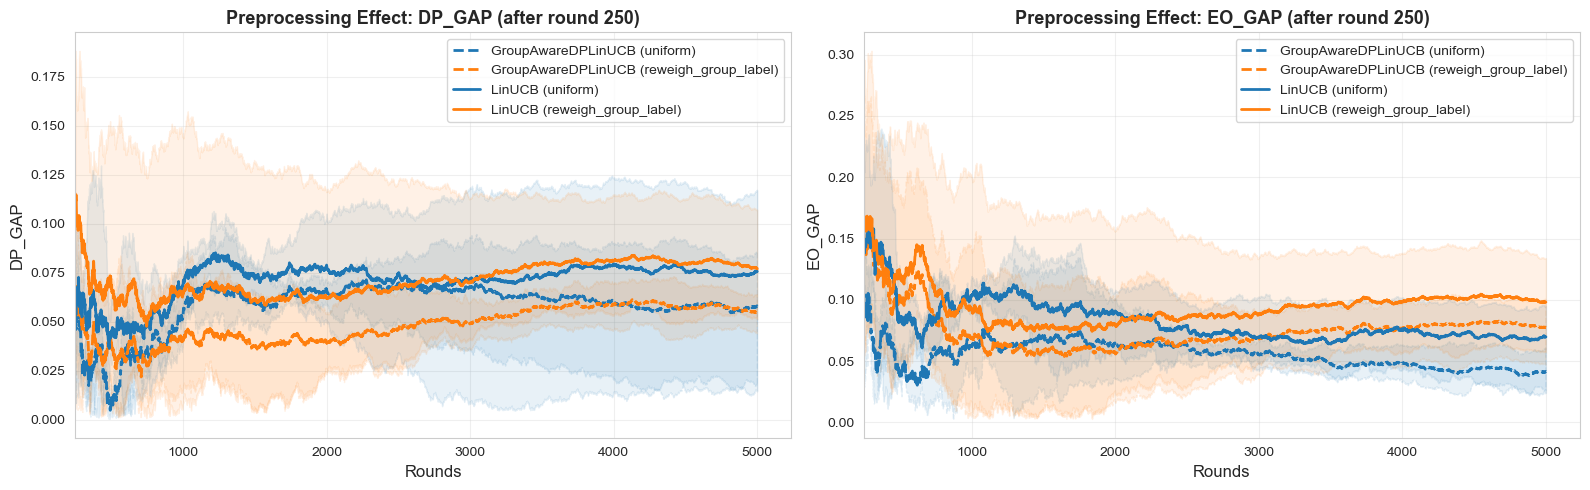

Preprocessing effect plot saved


In [4]:
def plot_preprocessing_effect(logs_df: pd.DataFrame, metric: str = 'dp_gap'):
    """
    Plot the effect of preprocessing on fairness metrics.
    Compares uniform sampling vs reweighted sampling for each policy.
    """
    zoom_start = globals().get('ZOOM_START', 250)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    policies = sorted(logs_df['policy'].unique())
    colors = {'uniform': '#1f77b4', 'reweigh_group_label': '#ff7f0e'}

    for ax, metric_name in zip(axes, ['dp_gap', 'eo_gap']):
        for policy in policies:
            for preprocessing in ['uniform', 'reweigh_group_label']:
                subset = logs_df[
                    (logs_df['policy'] == policy)
                    & (logs_df['preprocessing'] == preprocessing)
                ]

                agg = aggregate_temporal_over_seeds(
                    subset,
                    value_cols=[metric_name],
                    group_cols=['preprocessing'],
                    t_col='t',
                    seed_col='seed',
                    alpha=0.05,
                )

                agg = agg.sort_values('t')
                agg = agg[agg['t'] >= zoom_start]
                if agg.empty:
                    continue

                label = f"{policy} ({preprocessing})"
                color = colors[preprocessing]
                linestyle = '-' if policy == 'LinUCB' else '--'

                ax.plot(
                    agg['t'],
                    agg[f'{metric_name}_mean'],
                    label=label,
                    color=color,
                    linestyle=linestyle,
                    linewidth=2,
                )
                ax.fill_between(
                    agg['t'],
                    agg[f'{metric_name}_low'],
                    agg[f'{metric_name}_high'],
                    color=color,
                    alpha=0.1,
                    linestyle=linestyle,
                )

        ax.set_xlabel('Rounds', fontsize=12)
        ax.set_ylabel(f'{metric_name.upper()}', fontsize=12)
        ax.set_title(
            f'Preprocessing Effect: {metric_name.upper()} (after round {zoom_start})',
            fontsize=13,
            fontweight='bold',
        )
        ax.set_xlim(left=zoom_start)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

if 'logs_df' in locals() and not logs_df.empty:
    fig_preproc = plot_preprocessing_effect(logs_df)
    plt.savefig('results/dev/final_figures/preprocessing_effect.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Preprocessing effect plot saved")
else:
    print("Logs not available for preprocessing visualization")

## 2. Inprocessing: LinUCB (Baseline) vs GroupAwareDPLinUCB (Fair)

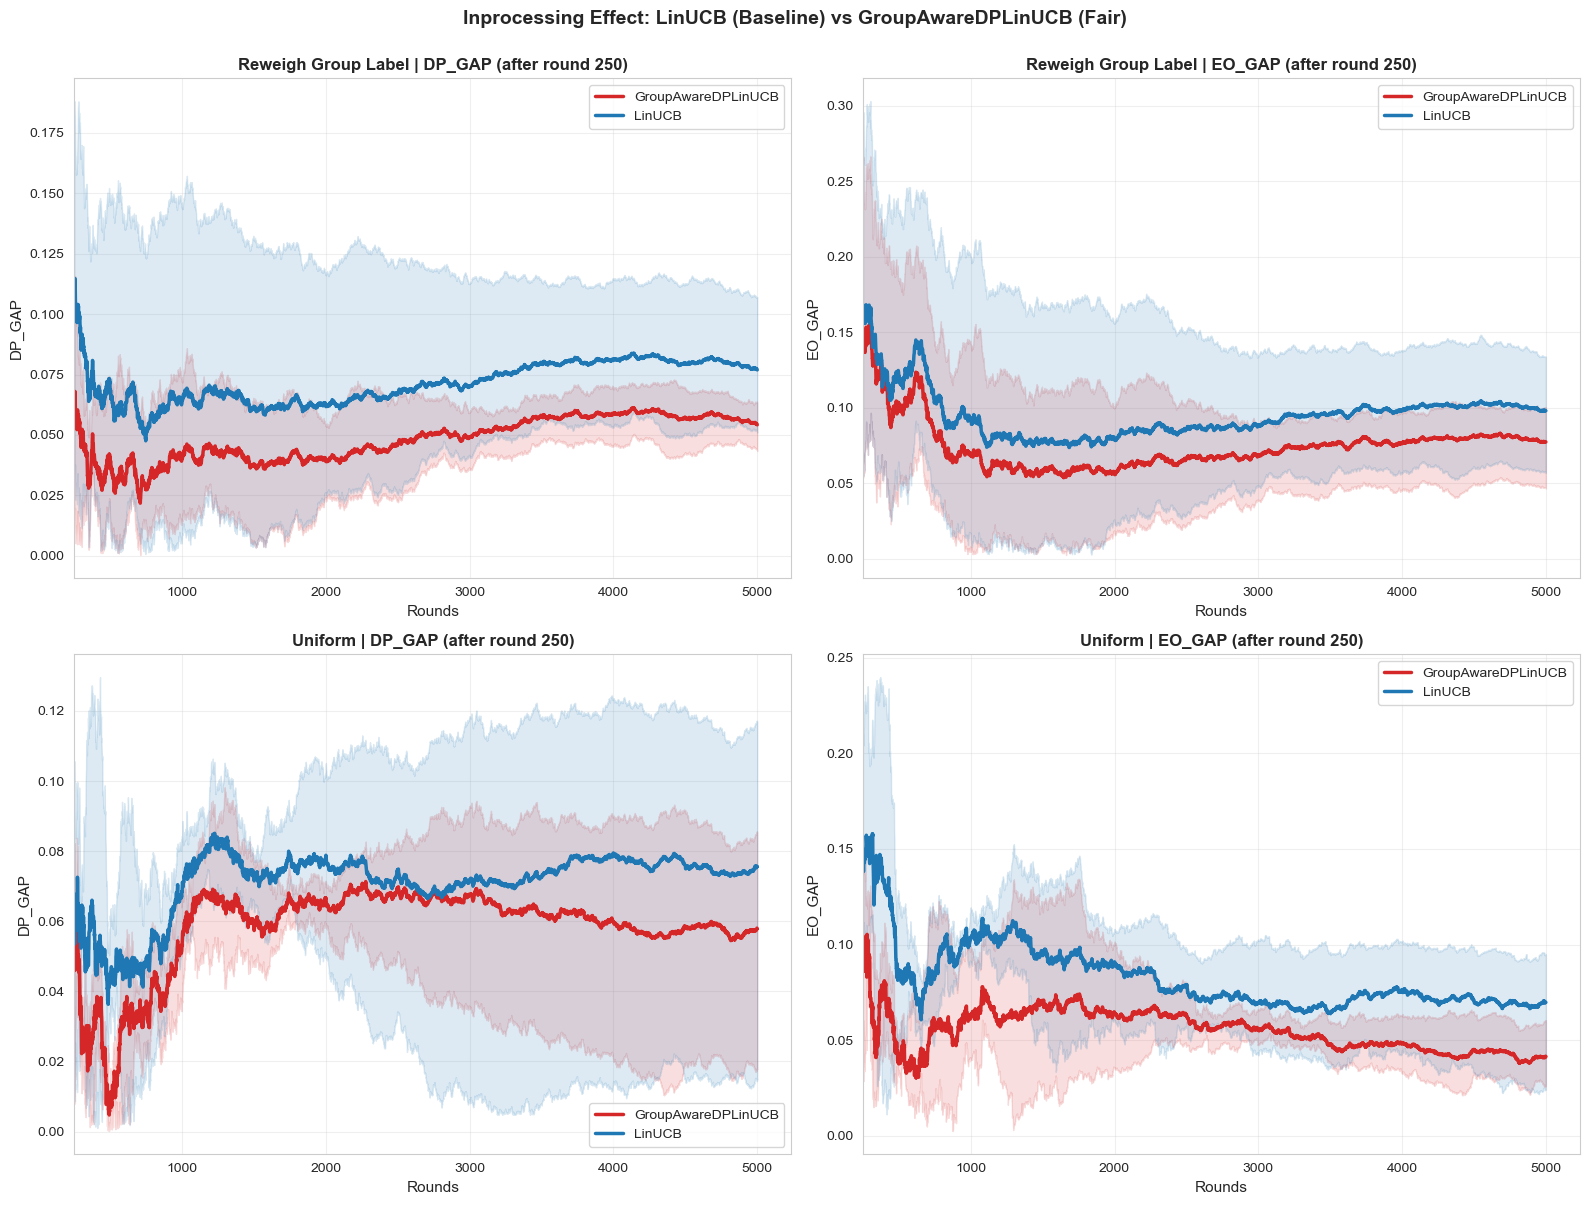

Inprocessing effect plot saved


In [5]:
def plot_inprocessing_effect(logs_df: pd.DataFrame):
    """
    Plot the effect of inprocessing (fair algorithms) on fairness metrics.
    Compares LinUCB vs GroupAwareDPLinUCB.
    """
    zoom_start = globals().get('ZOOM_START', 250)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        'Inprocessing Effect: LinUCB (Baseline) vs GroupAwareDPLinUCB (Fair)',
        fontsize=14,
        fontweight='bold',
        y=1.00,
    )

    preprocessings = sorted(logs_df['preprocessing'].unique())
    policies = sorted(logs_df['policy'].unique())
    colors = {'LinUCB': '#1f77b4', 'GroupAwareDPLinUCB': '#d62728'}

    for row, preprocessing in enumerate(preprocessings):
        for col, metric_name in enumerate(['dp_gap', 'eo_gap']):
            ax = axes[row, col]

            subset = logs_df[logs_df['preprocessing'] == preprocessing]

            for policy in policies:
                policy_data = subset[subset['policy'] == policy]

                agg = aggregate_temporal_over_seeds(
                    policy_data,
                    value_cols=[metric_name],
                    group_cols=['policy'],
                    t_col='t',
                    seed_col='seed',
                    alpha=0.05,
                )

                agg = agg.sort_values('t')
                agg = agg[agg['t'] >= zoom_start]
                if agg.empty:
                    continue

                color = colors.get(policy, '#1f77b4')

                ax.plot(
                    agg['t'],
                    agg[f'{metric_name}_mean'],
                    label=policy,
                    color=color,
                    linewidth=2.5,
                )
                ax.fill_between(
                    agg['t'],
                    agg[f'{metric_name}_low'],
                    agg[f'{metric_name}_high'],
                    color=color,
                    alpha=0.15,
                )

            ax.set_xlabel('Rounds', fontsize=11)
            ax.set_ylabel(f'{metric_name.upper()}', fontsize=11)
            ax.set_title(
                f'{preprocessing.replace("_", " ").title()} | {metric_name.upper()} (after round {zoom_start})',
                fontsize=12,
                fontweight='bold',
            )
            ax.set_xlim(left=zoom_start)
            ax.legend(loc='best', fontsize=10)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

if 'logs_df' in locals() and not logs_df.empty:
    fig_inproc = plot_inprocessing_effect(logs_df)
    Path('results/dev/final_figures').mkdir(parents=True, exist_ok=True)
    plt.savefig('results/dev/final_figures/inprocessing_effect.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Inprocessing effect plot saved")
else:
    print("Logs not available for inprocessing visualization")

## 3. Postprocessing: With and Without Postprocessor

In [6]:
# Load postprocessing results
postproc_perseed = None
postproc_ci = None

perseed_path = POSTPROC_DIR / "compas_postproc_perseed_long.csv"
ci_path = POSTPROC_DIR / "compas_postproc_ci_long.csv"

if perseed_path.exists():
    postproc_perseed = pd.read_csv(perseed_path)
    print(f"✓ Loaded postprocessing per-seed data: {len(postproc_perseed)} rows")
    display(postproc_perseed[['method', 'metric', 'value']].head(10))
else:
    print(f"Postprocessing per-seed data not found at {perseed_path}")

if ci_path.exists():
    postproc_ci = pd.read_csv(ci_path)
    print(f"Loaded postprocessing CI data: {len(postproc_ci)} rows")
else:
    print(f"Postprocessing CI data not found at {ci_path}")

✓ Loaded postprocessing per-seed data: 3200 rows


,method,metric,value
0,GroupAwareDPLinUCB,CumulativeRegret,746.000000
1,GroupAwareDPLinUCB,DP_gap,0.034006
2,GroupAwareDPLinUCB,EO_gap,0.080597
3,GroupAwareDPLinUCB,FPR_gap,0.045394
4,GroupAwareDPLinUCB,PPV_gap,0.100493
5,GroupAwareDPLinUCB,TPR_gap,0.080597
6,GroupAwareDPLinUCB,UtilityGap,0.014174
7,GroupAwareDPLinUCB,accuracy,0.655427
8,GroupAwareDPLinUCB_PostProc,CumulativeRegret,773.000000
9,GroupAwareDPLinUCB_PostProc,DP_gap,0.022943


Loaded postprocessing CI data: 640 rows


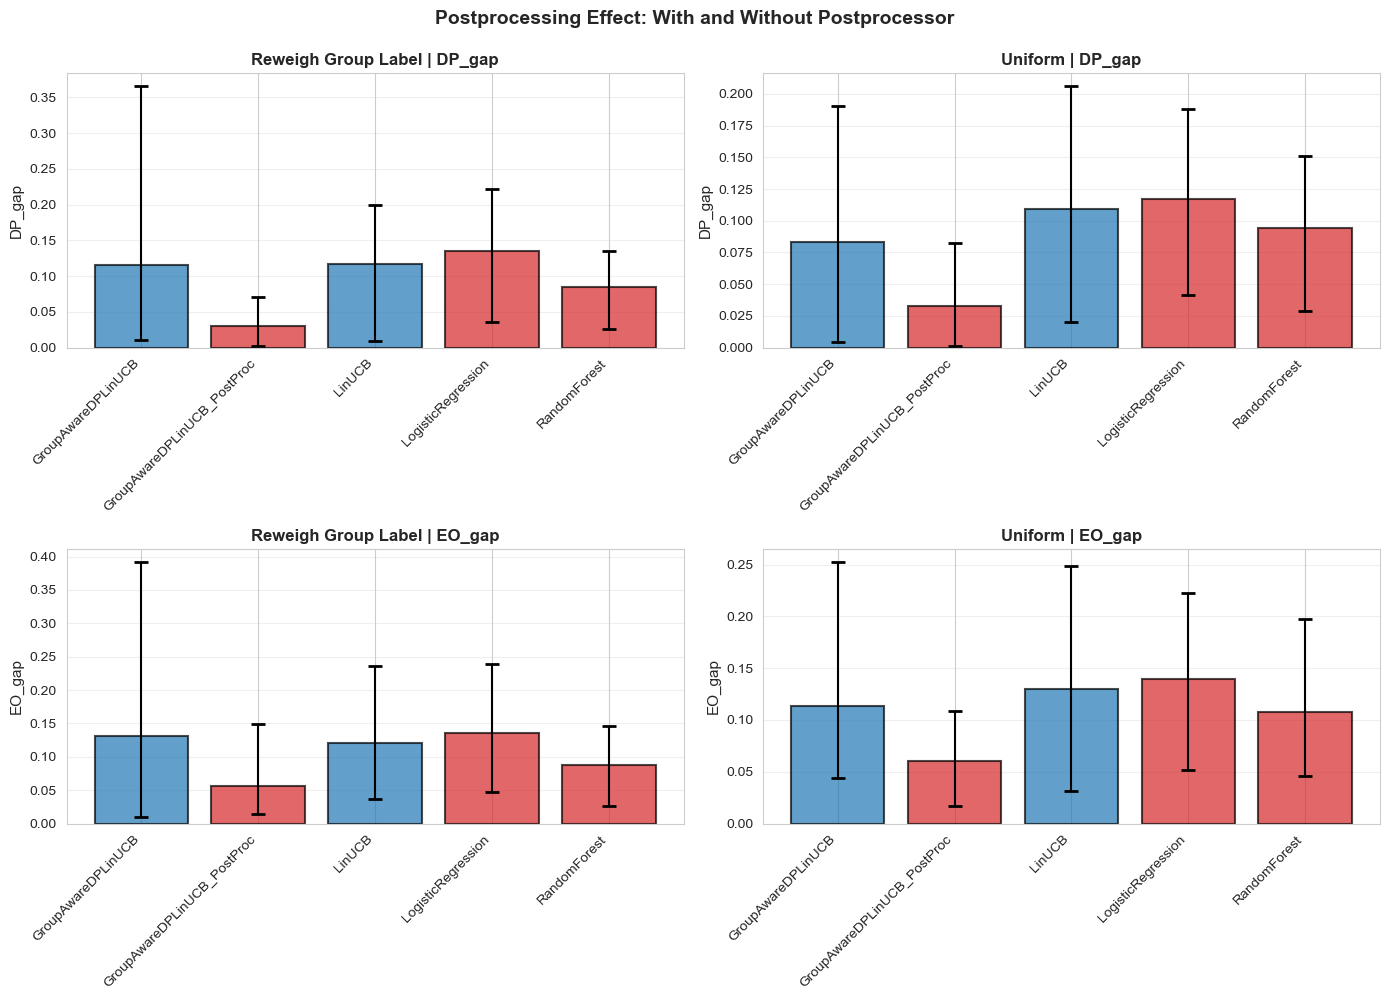

Postprocessing effect plot saved


In [7]:
def plot_postprocessing_effect(postproc_perseed: pd.DataFrame):
    """
    Plot the effect of postprocessing on fairness metrics.
    Compares methods with and without postprocessing.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Postprocessing Effect: With and Without Postprocessor', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Filter for relevant metrics and methods
    metrics_to_plot = ['DP_gap', 'EO_gap']
    methods = sorted(postproc_perseed['method'].unique())
    
    # Group methods
    base_methods = ['LinUCB', 'GroupAwareDPLinUCB']
    postproc_methods = ['GroupAwareDPLinUCB_PostProc']
    
    preprocessings = sorted(postproc_perseed['preprocessing'].unique())
    
    for row, metric in enumerate(metrics_to_plot):
        for col, preprocessing in enumerate(preprocessings):
            ax = axes[row, col]
            
            subset = postproc_perseed[
                (postproc_perseed['metric'] == metric) &
                (postproc_perseed['preprocessing'] == preprocessing)
            ]
            
            # Compute mean and CI for each method
            data_to_plot = []
            for method in methods:
                method_data = subset[subset['method'] == method]['value']
                if len(method_data) > 0:
                    mean_val = method_data.mean()
                    ci_low = method_data.quantile(0.025)
                    ci_high = method_data.quantile(0.975)
                    data_to_plot.append({
                        'method': method,
                        'mean': mean_val,
                        'ci_low': ci_low,
                        'ci_high': ci_high
                    })
            
            if data_to_plot:
                methods_plot = [d['method'] for d in data_to_plot]
                means = [d['mean'] for d in data_to_plot]
                ci_lows = [d['ci_low'] for d in data_to_plot]
                ci_highs = [d['ci_high'] for d in data_to_plot]
                errors = [
                    [m - l for m, l in zip(means, ci_lows)],
                    [h - m for h, m in zip(ci_highs, means)]
                ]
                
                colors = ['#1f77b4' if m in base_methods else '#d62728' for m in methods_plot]
                bars = ax.bar(range(len(methods_plot)), means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
                ax.errorbar(range(len(methods_plot)), means, yerr=errors, fmt='none', 
                           ecolor='black', capsize=5, capthick=2)
                
                ax.set_xticks(range(len(methods_plot)))
                ax.set_xticklabels(methods_plot, rotation=45, ha='right')
                ax.set_ylabel(f'{metric}', fontsize=11)
                ax.set_title(f'{preprocessing.replace("_", " ").title()} | {metric}', 
                            fontsize=12, fontweight='bold')
                ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

if postproc_perseed is not None and not postproc_perseed.empty:
    fig_postproc = plot_postprocessing_effect(postproc_perseed)
    plt.savefig('results/dev/final_figures/postprocessing_effect.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Postprocessing effect plot saved")
else:
    print("Postprocessing data not available for visualization")

## Summary: Comparative View of All Processing Methods

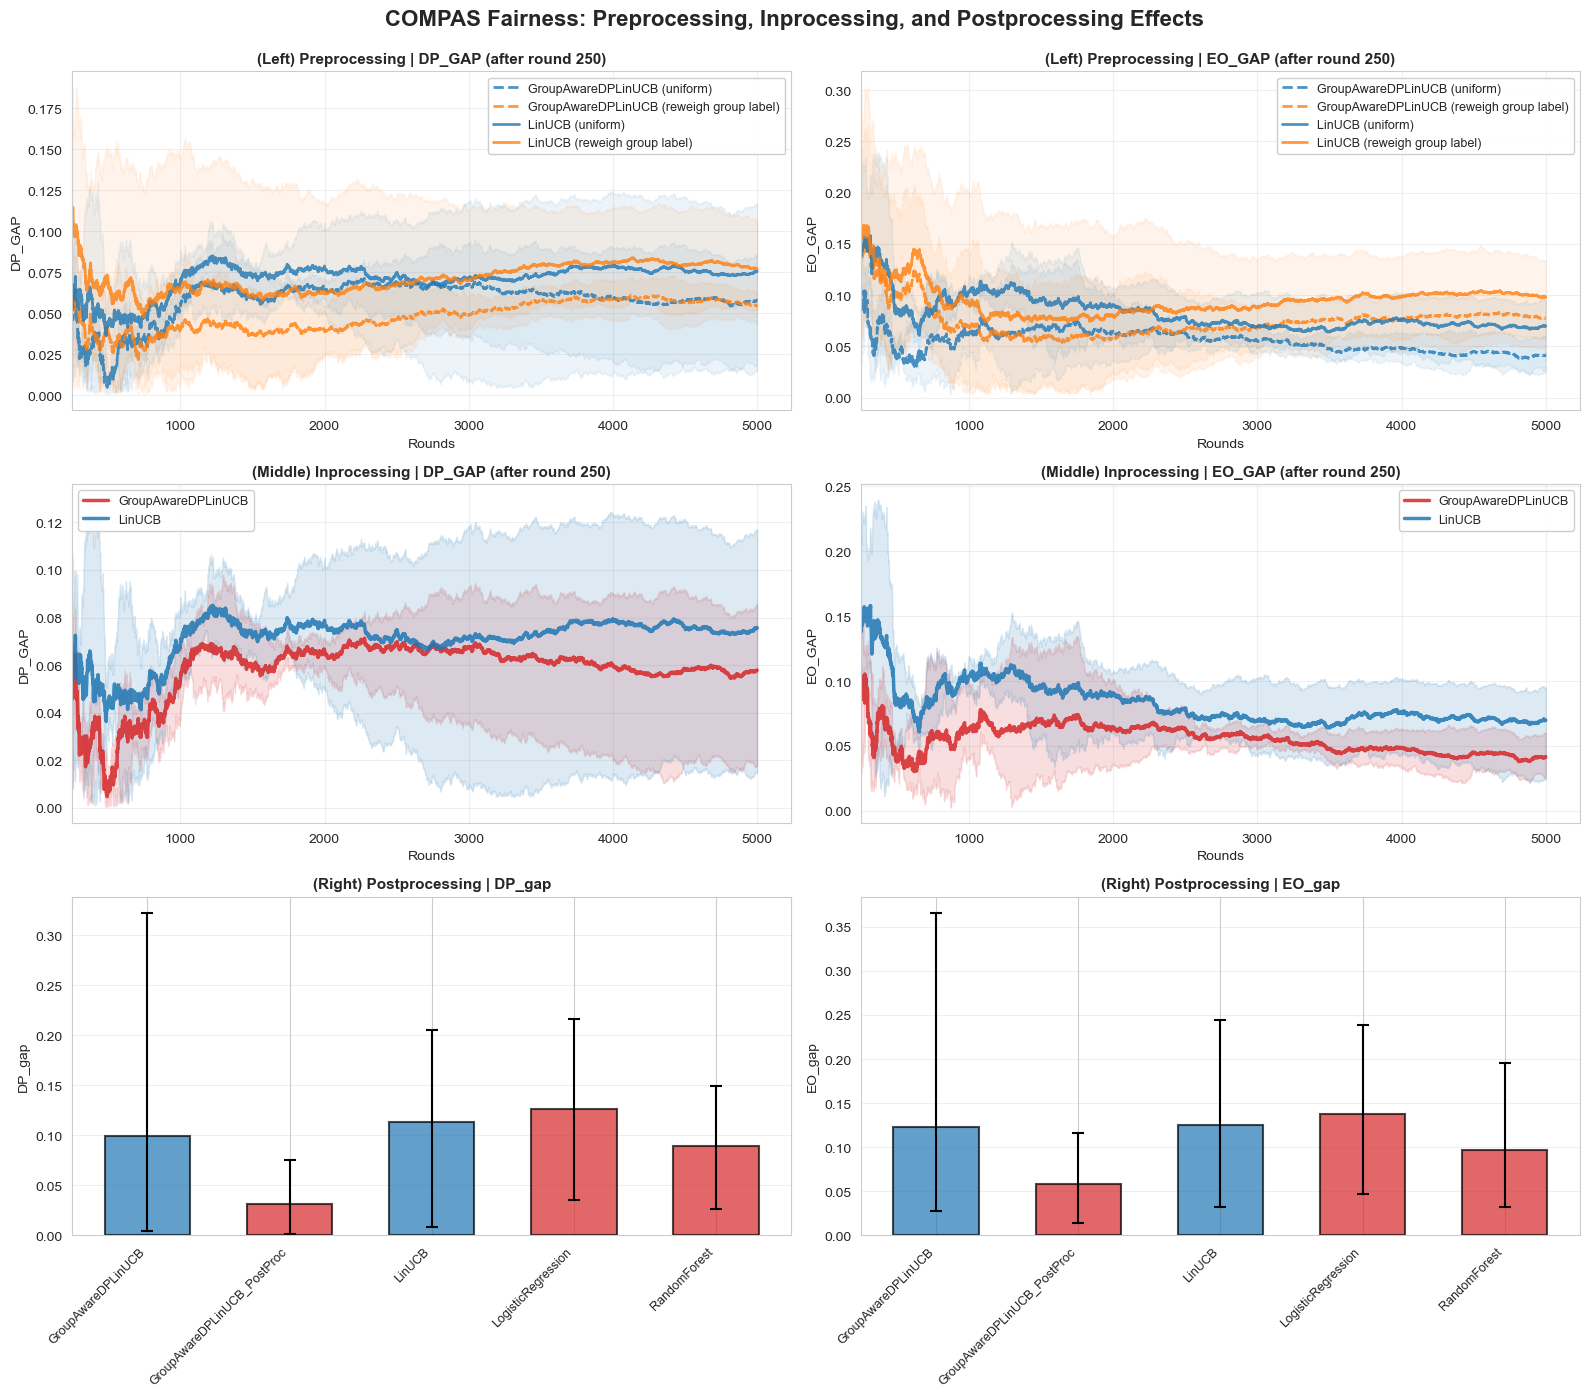

Combined processing methods visualization saved


In [8]:
def plot_combined_processing_methods(logs_df: pd.DataFrame, postproc_perseed: pd.DataFrame = None):
    """
    Create a comprehensive 3x2 grid showing:
    - Row 1: Preprocessing effect (uniform vs reweighted)
    - Row 2: Inprocessing effect (LinUCB vs Fair)
    - Row 3: Postprocessing effect (with/without postprocessor)
    Columns: DP-gap and EO-gap
    """
    zoom_start = globals().get('ZOOM_START', 250)
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle(
        'COMPAS Fairness: Preprocessing, Inprocessing, and Postprocessing Effects',
        fontsize=16,
        fontweight='bold',
        y=0.995,
    )

    policies = sorted(logs_df['policy'].unique())
    colors_preproc = {'uniform': '#1f77b4', 'reweigh_group_label': '#ff7f0e'}

    for col, metric_name in enumerate(['dp_gap', 'eo_gap']):
        ax = axes[0, col]

        for policy in policies:
            for preprocessing in ['uniform', 'reweigh_group_label']:
                subset = logs_df[
                    (logs_df['policy'] == policy)
                    & (logs_df['preprocessing'] == preprocessing)
                ]

                agg = aggregate_temporal_over_seeds(
                    subset,
                    value_cols=[metric_name],
                    group_cols=['preprocessing'],
                    t_col='t',
                    seed_col='seed',
                    alpha=0.05,
                )

                agg = agg.sort_values('t')
                agg = agg[agg['t'] >= zoom_start]
                if agg.empty:
                    continue

                label = f"{policy} ({preprocessing.replace('_', ' ')})"
                color = colors_preproc[preprocessing]
                linestyle = '-' if policy == 'LinUCB' else '--'

                ax.plot(
                    agg['t'],
                    agg[f'{metric_name}_mean'],
                    label=label,
                    color=color,
                    linestyle=linestyle,
                    linewidth=2,
                    alpha=0.8,
                )
                ax.fill_between(
                    agg['t'],
                    agg[f'{metric_name}_low'],
                    agg[f'{metric_name}_high'],
                    color=color,
                    alpha=0.08,
                    linestyle=linestyle,
                )

        ax.set_xlabel('Rounds', fontsize=10)
        ax.set_ylabel(f'{metric_name.upper()}', fontsize=10)
        ax.set_title(
            f'(Left) Preprocessing | {metric_name.upper()} (after round {zoom_start})',
            fontsize=11,
            fontweight='bold',
        )
        ax.set_xlim(left=zoom_start)
        ax.legend(loc='best', fontsize=9, framealpha=0.95)
        ax.grid(True, alpha=0.3)

    colors_inproc = {'LinUCB': '#1f77b4', 'GroupAwareDPLinUCB': '#d62728'}
    preprocessing_to_use = 'uniform'

    for col, metric_name in enumerate(['dp_gap', 'eo_gap']):
        ax = axes[1, col]

        subset = logs_df[logs_df['preprocessing'] == preprocessing_to_use]

        for policy in sorted(policies):
            policy_data = subset[subset['policy'] == policy]

            agg = aggregate_temporal_over_seeds(
                policy_data,
                value_cols=[metric_name],
                group_cols=['policy'],
                t_col='t',
                seed_col='seed',
                alpha=0.05,
            )

            agg = agg.sort_values('t')
            agg = agg[agg['t'] >= zoom_start]
            if agg.empty:
                continue

            color = colors_inproc.get(policy, '#1f77b4')

            ax.plot(
                agg['t'],
                agg[f'{metric_name}_mean'],
                label=policy,
                color=color,
                linewidth=2.5,
                alpha=0.85,
            )
            ax.fill_between(
                agg['t'],
                agg[f'{metric_name}_low'],
                agg[f'{metric_name}_high'],
                color=color,
                alpha=0.15,
            )

        ax.set_xlabel('Rounds', fontsize=10)
        ax.set_ylabel(f'{metric_name.upper()}', fontsize=10)
        ax.set_title(
            f'(Middle) Inprocessing | {metric_name.upper()} (after round {zoom_start})',
            fontsize=11,
            fontweight='bold',
        )
        ax.set_xlim(left=zoom_start)
        ax.legend(loc='best', fontsize=9, framealpha=0.95)
        ax.grid(True, alpha=0.3)

    if postproc_perseed is not None and not postproc_perseed.empty:
        for col, metric in enumerate(['DP_gap', 'EO_gap']):
            ax = axes[2, col]

            subset = postproc_perseed[postproc_perseed['metric'] == metric]

            data_to_plot = []
            methods_list = []
            for method in sorted(subset['method'].unique()):
                method_data = subset[subset['method'] == method]['value']
                if len(method_data) > 0:
                    mean_val = method_data.mean()
                    ci_low = method_data.quantile(0.025)
                    ci_high = method_data.quantile(0.975)
                    data_to_plot.append({
                        'method': method,
                        'mean': mean_val,
                        'ci_low': ci_low,
                        'ci_high': ci_high,
                    })
                    methods_list.append(method)

            if data_to_plot:
                means = [d['mean'] for d in data_to_plot]
                errors_low = [m - d['ci_low'] for m, d in zip(means, data_to_plot)]
                errors_high = [d['ci_high'] - m for m, d in zip(means, data_to_plot)]

                colors_bar = [
                    '#1f77b4' if m in ['LinUCB', 'GroupAwareDPLinUCB'] else '#d62728'
                    for m in methods_list
                ]

                ax.bar(
                    range(len(methods_list)),
                    means,
                    color=colors_bar,
                    alpha=0.7,
                    edgecolor='black',
                    linewidth=1.5,
                    width=0.6,
                )
                ax.errorbar(
                    range(len(methods_list)),
                    means,
                    yerr=[errors_low, errors_high],
                    fmt='none',
                    ecolor='black',
                    capsize=4,
                    capthick=1.5,
                )

                ax.set_xticks(range(len(methods_list)))
                ax.set_xticklabels(methods_list, rotation=45, ha='right', fontsize=9)
                ax.set_ylabel(f'{metric}', fontsize=10)
                ax.set_title(
                    f'(Right) Postprocessing | {metric}',
                    fontsize=11,
                    fontweight='bold',
                )
                ax.grid(True, alpha=0.3, axis='y')
    else:
        axes[2, 0].text(
            0.5,
            0.5,
            'Postprocessing data not available',
            ha='center',
            va='center',
            transform=axes[2, 0].transAxes,
            fontsize=12,
        )
        axes[2, 1].text(
            0.5,
            0.5,
            'Postprocessing data not available',
            ha='center',
            va='center',
            transform=axes[2, 1].transAxes,
            fontsize=12,
        )
        axes[2, 0].set_xticks([])
        axes[2, 0].set_yticks([])
        axes[2, 1].set_xticks([])
        axes[2, 1].set_yticks([])

    plt.tight_layout()
    return fig

if 'logs_df' in locals() and not logs_df.empty:
    fig_combined = plot_combined_processing_methods(logs_df, postproc_perseed)
    Path('results/dev/final_figures').mkdir(parents=True, exist_ok=True)
    plt.savefig('results/dev/final_figures/combined_processing_methods.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Combined processing methods visualization saved")
else:
    print("Data not available for combined visualization")

## Key Insights and Analysis

In [9]:
print("=" * 80)
print("FAIRNESS INTERVENTION ANALYSIS SUMMARY")
print("=" * 80)

if 'logs_df' in locals() and not logs_df.empty:
    print("\n1. PREPROCESSING EFFECTS")
    print("-" * 80)
    
    for policy in sorted(logs_df['policy'].unique()):
        print(f"\n  Policy: {policy}")
        for preprocessing in ['uniform', 'reweigh_group_label']:
            subset = logs_df[
                (logs_df['policy'] == policy) & 
                (logs_df['preprocessing'] == preprocessing)
            ]
            
            if not subset.empty:
                final_dp_gap = subset.groupby('seed')['dp_gap'].last().mean()
                final_eo_gap = subset.groupby('seed')['eo_gap'].last().mean()
                
                print(f"    {preprocessing:25s}: DP-gap={final_dp_gap:.4f}, EO-gap={final_eo_gap:.4f}")

    print("\n2. INPROCESSING EFFECTS")
    print("-" * 80)
    
    for preprocessing in sorted(logs_df['preprocessing'].unique()):
        print(f"\n  Preprocessing: {preprocessing}")
        subset = logs_df[logs_df['preprocessing'] == preprocessing]
        
        for policy in sorted(subset['policy'].unique()):
            policy_data = subset[subset['policy'] == policy]
            
            if not policy_data.empty:
                final_dp_gap = policy_data.groupby('seed')['dp_gap'].last().mean()
                final_eo_gap = policy_data.groupby('seed')['eo_gap'].last().mean()
                
                print(f"    {policy:25s}: DP-gap={final_dp_gap:.4f}, EO-gap={final_eo_gap:.4f}")

if postproc_perseed is not None and not postproc_perseed.empty:
    print("\n3. POSTPROCESSING EFFECTS")
    print("-" * 80)
    
    for metric in ['DP_gap', 'EO_gap']:
        print(f"\n  Metric: {metric}")
        subset = postproc_perseed[postproc_perseed['metric'] == metric]
        
        for method in sorted(subset['method'].unique()):
            method_data = subset[subset['method'] == method]['value']
            if len(method_data) > 0:
                mean_val = method_data.mean()
                ci_low = method_data.quantile(0.025)
                ci_high = method_data.quantile(0.975)
                print(f"    {method:35s}: {mean_val:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

FAIRNESS INTERVENTION ANALYSIS SUMMARY

1. PREPROCESSING EFFECTS
--------------------------------------------------------------------------------

  Policy: GroupAwareDPLinUCB
    uniform                  : DP-gap=0.0579, EO-gap=0.0414
    reweigh_group_label      : DP-gap=0.0542, EO-gap=0.0775

  Policy: LinUCB
    uniform                  : DP-gap=0.0756, EO-gap=0.0698
    reweigh_group_label      : DP-gap=0.0769, EO-gap=0.0981

2. INPROCESSING EFFECTS
--------------------------------------------------------------------------------

  Preprocessing: reweigh_group_label
    GroupAwareDPLinUCB       : DP-gap=0.0542, EO-gap=0.0775
    LinUCB                   : DP-gap=0.0769, EO-gap=0.0981

  Preprocessing: uniform
    GroupAwareDPLinUCB       : DP-gap=0.0579, EO-gap=0.0414
    LinUCB                   : DP-gap=0.0756, EO-gap=0.0698

3. POSTPROCESSING EFFECTS
--------------------------------------------------------------------------------

  Metric: DP_gap
    GroupAwareDPLinUCB        